# PyDESeq2 Workflow


May 16, 2025

This notebook presents a differential gene expression analysis using the PyDESeq2 package, a Python implementation of the widely used DESeq2 method originally developed for R. The analysis focuses on identifying genes whose expression levels significantly differ between experimental conditions (e.g., disease vs. control), using count-based RNA-seq data.

Differential expression analysis is a critical step in transcriptomics workflows, as it allows researchers to pinpoint genes that may play key roles in biological processes, disease mechanisms, or therapeutic responses. DESeq2 uses a model based on the negative binomial distribution to account for biological variability and library size differences, providing robust statistical testing for differential expression.

PyDESeq2 brings this powerful methodology to the Python ecosystem, enabling seamless integration with other tools in data science and machine learning workflows. In this notebook, we perform the full PyDESeq2 pipeline, including normalization, dispersion estimation, model fitting, and hypothesis testing. We also include visualization steps (e.g., PCA, volcano plot) to interpret and communicate the results effectively.

This analysis provides a foundation for downstream functional enrichment, biomarker discovery, or predictive modeling, depending on the research objectives.





https://pydeseq2.readthedocs.io/en/latest/auto_examples/plot_minimal_pydeseq2_pipeline.html#data-loading

In [86]:
import os
import pickle as pkl
import numpy as np
import pandas as pd
import anndata
import matplotlib.pyplot as plt
import seaborn as sns

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data

# Print version information for documentation
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("anndata:", anndata.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)

SAVE = False  # whether to save the outputs of this notebook

if SAVE:
    # Replace this with the path to directory where you would like results to be saved
    OUTPUT_PATH = "../results/smoc2_analysis"
    os.makedirs(OUTPUT_PATH, exist_ok=True)  # Create path if it doesn't exist

pandas: 2.2.3
numpy: 1.26.4
anndata: 0.10.9
matplotlib: 3.7.2
seaborn: 0.12.2


# Data Loading

To perform differential expression analysis (DEA), PyDESeq2 requires two types of inputs:

A count matrix of shape ‘number of samples’ x ‘number of genes’, containing read counts (non-negative integers),

Metadata (or “column” data) of shape ‘number of samples’ x ‘number of variables’, containing sample annotations that will be used to split the data in cohorts.

Both should be provided as pandas dataframes.

To illustrate the required data format, we load a synthetic example dataset that may be obtained through PyDESeq2’s API using utils.load_example_data(). You may replace it with your own dataset.



In [2]:
smoc2_rawcounts = pd.read_csv('https://assets.datacamp.com/production/repositories/1766/datasets/bf1d0eff910f1b2cad36e5acdc2a182e95c63965/fibrosis_smoc2_rawcounts_unordered.csv')
# Explore the first six observations of smoc2_rawcounts
smoc2_rawcounts.head()

# Explore the structure of smoc2_rawcounts
smoc2_rawcounts.describe()


,smoc2_fibrosis1,smoc2_fibrosis4,smoc2_normal1,smoc2_normal3,smoc2_fibrosis3,smoc2_normal4,smoc2_fibrosis2
count,47729.000000,47729.000000,47729.000000,47729.000000,47729.000000,47729.000000,47729.000000
mean,579.747847,452.220579,408.221291,462.207631,512.294182,502.731023,466.278049
std,3635.322005,3202.642350,4699.030916,6049.114257,3448.861168,5651.474342,3377.210444
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,184.000000,144.000000,63.000000,75.000000,165.000000,72.000000,143.000000
max,420026.000000,392520.000000,499174.000000,643989.000000,347826.000000,655931.000000,467692.000000


In [3]:
smoc2_rawcounts

,Unnamed: 0,smoc2_fibrosis1,smoc2_fibrosis4,smoc2_normal1,smoc2_normal3,smoc2_fibrosis3,smoc2_normal4,smoc2_fibrosis2
0,ENSMUSG00000102693,0,0,0,0,0,0,0
1,ENSMUSG00000064842,0,0,0,0,0,0,0
2,ENSMUSG00000051951,72,30,0,3,36,1,51
3,ENSMUSG00000102851,0,0,0,0,0,0,0
4,ENSMUSG00000103377,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...
47724,ENSMUSG00000094431,0,0,0,0,0,0,0
47725,ENSMUSG00000094621,0,1,0,0,0,1,0
47726,ENSMUSG00000098647,0,0,0,0,0,0,0
47727,ENSMUSG00000096730,0,0,0,0,0,0,0


In [4]:
# Set the index to the Unamed and rename it Gene_ID
smoc2_rawcounts = smoc2_rawcounts.set_index("Unnamed: 0")
smoc2_rawcounts.index.name = "Gene_ID"


In [5]:
smoc2_rawcounts

,smoc2_fibrosis1,smoc2_fibrosis4,smoc2_normal1,smoc2_normal3,smoc2_fibrosis3,smoc2_normal4,smoc2_fibrosis2
Gene_ID,,,,,,,
ENSMUSG00000102693,0,0,0,0,0,0,0
ENSMUSG00000064842,0,0,0,0,0,0,0
ENSMUSG00000051951,72,30,0,3,36,1,51
ENSMUSG00000102851,0,0,0,0,0,0,0
ENSMUSG00000103377,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...
ENSMUSG00000094431,0,0,0,0,0,0,0
ENSMUSG00000094621,0,1,0,0,0,1,0
ENSMUSG00000098647,0,0,0,0,0,0,0


In [6]:
#You end up with a filtered version of smoc2_rawcounts that excludes genes with zero counts across all samples.
smoc2_rawcounts = smoc2_rawcounts[smoc2_rawcounts.sum(axis = 1) > 0]


In [7]:
smoc2_rawcounts

,smoc2_fibrosis1,smoc2_fibrosis4,smoc2_normal1,smoc2_normal3,smoc2_fibrosis3,smoc2_normal4,smoc2_fibrosis2
Gene_ID,,,,,,,
ENSMUSG00000051951,72,30,0,3,36,1,51
ENSMUSG00000103377,0,0,1,0,0,0,0
ENSMUSG00000103147,1,1,1,0,1,0,1
ENSMUSG00000103161,0,1,0,0,0,0,0
ENSMUSG00000102331,9,2,1,1,7,1,3
...,...,...,...,...,...,...,...
ENSMUSG00000095041,5886,4404,1808,1642,4793,1409,3940
ENSMUSG00000063897,816,595,509,559,818,688,733
ENSMUSG00000084520,0,0,0,0,1,0,0


In [8]:
#Transpose it into the correct format with Genes as columns and samples as rows
smoc2_rawcounts = smoc2_rawcounts.T

In [9]:
smoc2_rawcounts

Gene_ID,ENSMUSG00000051951,ENSMUSG00000103377,ENSMUSG00000103147,ENSMUSG00000103161,ENSMUSG00000102331,ENSMUSG00000025900,ENSMUSG00000025902,ENSMUSG00000104238,ENSMUSG00000102269,ENSMUSG00000096126,...,ENSMUSG00000079222,ENSMUSG00000062783,ENSMUSG00000079192,ENSMUSG00000079794,ENSMUSG00000079808,ENSMUSG00000095041,ENSMUSG00000063897,ENSMUSG00000084520,ENSMUSG00000094621,ENSMUSG00000095742
smoc2_fibrosis1,72,0,1,0,9,5,486,0,7,2,...,0,23,2,1,1,5886,816,0,0,1397
smoc2_fibrosis4,30,0,1,1,2,4,257,0,2,0,...,1,3,0,0,8,4404,595,0,1,673
smoc2_normal1,0,1,1,0,1,11,262,1,12,0,...,0,0,0,0,0,1808,509,0,0,192
smoc2_normal3,3,0,0,0,1,17,356,0,9,1,...,0,0,0,0,0,1642,559,0,0,230
smoc2_fibrosis3,36,0,1,0,7,9,427,0,5,0,...,1,20,0,0,1,4793,818,1,0,1646
smoc2_normal4,1,0,0,0,1,26,355,0,3,0,...,0,0,0,0,0,1409,688,0,1,236
smoc2_fibrosis2,51,0,1,0,3,3,313,1,5,1,...,1,9,0,0,4,3940,733,0,0,1149


## Create Metadata

DGE Theory: Metadata
Use the information below to create a metadata data frame for the fibrosis count data called metadata with columns genotype and condition. The sample names (e.g. smoc2_fibrosis1, smoc2_fibrosis2, etc.) should be the row names of the data frame:


In [11]:
# Create genotype list
genotype = ["smoc2_oe"] * 7

# Create condition list
condition = ["fibrosis", "fibrosis", "fibrosis", "fibrosis", "normal", "normal", "normal"]

# Create DataFrame
smoc2_metadata = pd.DataFrame({
    'condition': condition,
    'genotype': genotype
})

# Assign the row names of the DataFrame
smoc2_metadata.index = ["smoc2_fibrosis1", "smoc2_fibrosis2", "smoc2_fibrosis3", "smoc2_fibrosis4", "smoc2_normal1", "smoc2_normal3", "smoc2_normal4"]

print(smoc2_metadata)


                condition  genotype
smoc2_fibrosis1  fibrosis  smoc2_oe
smoc2_fibrosis2  fibrosis  smoc2_oe
smoc2_fibrosis3  fibrosis  smoc2_oe
smoc2_fibrosis4  fibrosis  smoc2_oe
smoc2_normal1      normal  smoc2_oe
smoc2_normal3      normal  smoc2_oe
smoc2_normal4      normal  smoc2_oe


In [12]:
smoc2_metadata

,condition,genotype
smoc2_fibrosis1,fibrosis,smoc2_oe
smoc2_fibrosis2,fibrosis,smoc2_oe
smoc2_fibrosis3,fibrosis,smoc2_oe
smoc2_fibrosis4,fibrosis,smoc2_oe
smoc2_normal1,normal,smoc2_oe
smoc2_normal3,normal,smoc2_oe
smoc2_normal4,normal,smoc2_oe


In [13]:
# Reorder rows of smoc2_rawcounts to match the metadata index
smoc2_rawcounts = smoc2_rawcounts.loc[smoc2_metadata.index]


In [14]:
smoc2_rawcounts

Gene_ID,ENSMUSG00000051951,ENSMUSG00000103377,ENSMUSG00000103147,ENSMUSG00000103161,ENSMUSG00000102331,ENSMUSG00000025900,ENSMUSG00000025902,ENSMUSG00000104238,ENSMUSG00000102269,ENSMUSG00000096126,...,ENSMUSG00000079222,ENSMUSG00000062783,ENSMUSG00000079192,ENSMUSG00000079794,ENSMUSG00000079808,ENSMUSG00000095041,ENSMUSG00000063897,ENSMUSG00000084520,ENSMUSG00000094621,ENSMUSG00000095742
smoc2_fibrosis1,72,0,1,0,9,5,486,0,7,2,...,0,23,2,1,1,5886,816,0,0,1397
smoc2_fibrosis2,51,0,1,0,3,3,313,1,5,1,...,1,9,0,0,4,3940,733,0,0,1149
smoc2_fibrosis3,36,0,1,0,7,9,427,0,5,0,...,1,20,0,0,1,4793,818,1,0,1646
smoc2_fibrosis4,30,0,1,1,2,4,257,0,2,0,...,1,3,0,0,8,4404,595,0,1,673
smoc2_normal1,0,1,1,0,1,11,262,1,12,0,...,0,0,0,0,0,1808,509,0,0,192
smoc2_normal3,3,0,0,0,1,17,356,0,9,1,...,0,0,0,0,0,1642,559,0,0,230
smoc2_normal4,1,0,0,0,1,26,355,0,3,0,...,0,0,0,0,0,1409,688,0,1,236


In [15]:
smoc2_metadata

,condition,genotype
smoc2_fibrosis1,fibrosis,smoc2_oe
smoc2_fibrosis2,fibrosis,smoc2_oe
smoc2_fibrosis3,fibrosis,smoc2_oe
smoc2_fibrosis4,fibrosis,smoc2_oe
smoc2_normal1,normal,smoc2_oe
smoc2_normal3,normal,smoc2_oe
smoc2_normal4,normal,smoc2_oe


## Data Filtering

Before proceeding with DEA, it is good practice to preprocess your data, e.g. to remove samples for which annotations are missing and exclude genes with very low levels of expression. This is not necessary in the case of our synthetic data, but don’t forget this step if you are using real data. To this end you can use the code below.

We start by removing samples for which condition is NaN. If you are using another dataset, do not forget to change “condition” for the column of metadata you wish to use as a design factor in your analysis.



In [20]:
# Create a boolean mask for samples with non-missing condition values
samples_to_keep = smoc2_metadata['condition'].notna()

# Sanity check: make sure the indices match
assert all(smoc2_metadata.index == smoc2_rawcounts.index), "Metadata and raw counts indices do not match."

# Filter the counts by samples with valid metadata
counts_df = smoc2_rawcounts.loc[samples_to_keep, :]


In [22]:
counts_df

Gene_ID,ENSMUSG00000051951,ENSMUSG00000103377,ENSMUSG00000103147,ENSMUSG00000103161,ENSMUSG00000102331,ENSMUSG00000025900,ENSMUSG00000025902,ENSMUSG00000104238,ENSMUSG00000102269,ENSMUSG00000096126,...,ENSMUSG00000079222,ENSMUSG00000062783,ENSMUSG00000079192,ENSMUSG00000079794,ENSMUSG00000079808,ENSMUSG00000095041,ENSMUSG00000063897,ENSMUSG00000084520,ENSMUSG00000094621,ENSMUSG00000095742
smoc2_fibrosis1,72,0,1,0,9,5,486,0,7,2,...,0,23,2,1,1,5886,816,0,0,1397
smoc2_fibrosis2,51,0,1,0,3,3,313,1,5,1,...,1,9,0,0,4,3940,733,0,0,1149
smoc2_fibrosis3,36,0,1,0,7,9,427,0,5,0,...,1,20,0,0,1,4793,818,1,0,1646
smoc2_fibrosis4,30,0,1,1,2,4,257,0,2,0,...,1,3,0,0,8,4404,595,0,1,673
smoc2_normal1,0,1,1,0,1,11,262,1,12,0,...,0,0,0,0,0,1808,509,0,0,192
smoc2_normal3,3,0,0,0,1,17,356,0,9,1,...,0,0,0,0,0,1642,559,0,0,230
smoc2_normal4,1,0,0,0,1,26,355,0,3,0,...,0,0,0,0,0,1409,688,0,1,236


Next, we filter out genes that have less than 10 read counts in total. Note again that there are no such genes in this synthetic dataset.



In [23]:
genes_to_keep = counts_df.columns[counts_df.sum(axis=0) >= 10]
counts_df = counts_df[genes_to_keep]


In [24]:
counts_df

Gene_ID,ENSMUSG00000051951,ENSMUSG00000102331,ENSMUSG00000025900,ENSMUSG00000025902,ENSMUSG00000102269,ENSMUSG00000104328,ENSMUSG00000098104,ENSMUSG00000103922,ENSMUSG00000033845,ENSMUSG00000102275,...,ENSMUSG00000064372,ENSMUSG00000051412,ENSMUSG00000061654,ENSMUSG00000079834,ENSMUSG00000079190,ENSMUSG00000062783,ENSMUSG00000079808,ENSMUSG00000095041,ENSMUSG00000063897,ENSMUSG00000095742
smoc2_fibrosis1,72,9,5,486,7,2,7,8,1342,30,...,516,782,9,377,3,23,1,5886,816,1397
smoc2_fibrosis2,51,3,3,313,5,1,18,5,1085,20,...,569,682,6,316,2,9,4,3940,733,1149
smoc2_fibrosis3,36,7,9,427,5,3,10,7,1338,33,...,793,630,9,312,2,20,1,4793,818,1646
smoc2_fibrosis4,30,2,4,257,2,4,9,2,1146,18,...,701,512,6,339,3,3,8,4404,595,673
smoc2_normal1,0,1,11,262,12,3,2,17,1283,13,...,460,469,11,446,0,0,0,1808,509,192
smoc2_normal3,3,1,17,356,9,0,6,8,1460,19,...,1089,384,18,486,0,0,0,1642,559,230
smoc2_normal4,1,1,26,355,3,2,11,4,1690,21,...,967,517,18,604,0,0,0,1409,688,236


In this first analysis, we ignore the group variable and use the condition column as our design factor. That is, we compare gene expressions of samples that have condition B to those that have condition A.

Read counts modeling with the DeseqDataSet class
We start by creating a DeseqDataSet object from the count and metadata data. A DeseqDataSet fits dispersion and log-fold change (LFC) parameters from the data, and stores them.



## Create an Adata object

The adata object is an instance of the AnnData class from the anndata Python package. It's a powerful and flexible data structure designed for storing annotated data matrices, especially in bioinformatics and single-cell genomics—but it's also useful for bulk RNA-seq data like you're working with.

AnnData is a container that holds:

A data matrix (e.g., gene expression counts)
Annotations for rows (samples or cells)
Annotations for columns (genes or features)
Optional layers, metadata, and more

In [44]:
#Create an adata object
adata = anndata.AnnData(
    X=counts_df.values,
    obs=smoc2_metadata,
    var=pd.DataFrame(index=counts_df.columns)
)

In [45]:
adata

AnnData object with n_obs × n_vars = 7 × 21835
    obs: 'condition', 'genotype'

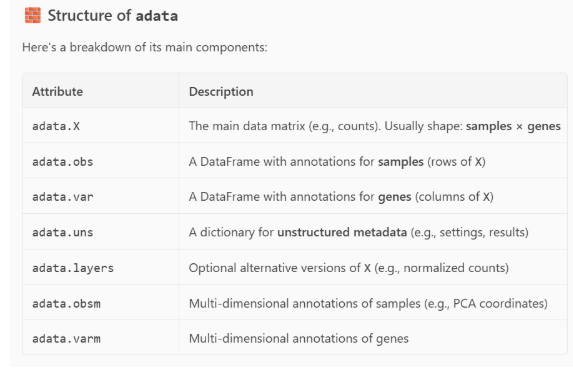

X: the raw count matrix (samples as rows, genes as columns)

obs: metadata for each sample (like condition labels)

var: gene names (used as column labels for X)


Read counts modeling with the DeseqDataSet class
We start by creating a DeseqDataSet object from the count and metadata data. A DeseqDataSet fits dispersion and log-fold change (LFC) parameters from the data, and stores them.



## Create a DESeqDataSet 

This is a class from the pydeseq2 package that encapsulates your input data and analysis settings. It wraps around your AnnData object and prepares it for the DESeq2-style modeling pipeline (normalization, dispersion estimation, model fitting, etc.).

This passes your RNA-seq count data stored in an AnnData object (commonly used in single-cell and bulk RNA-seq workflows). adata contains:

.X: your count matrix (genes × samples),

.obs: sample-level metadata (like condition labels),

.var: gene-level metadata (optional but sometimes useful).



In [46]:
# Create the DESeq2 dataset from AnnData
#A DeseqDataSet has two mandatory arguments: a counts and a metadata dataframe, like the ones we’ve loaded in the first part of this tutorial.
inference = DefaultInference(n_cpus=8)

In [81]:
inference

In [48]:
dds = DeseqDataSet(
    adata=adata,
    refit_cooks=False, # This avoids the incompatible Series assignment
    inference=DefaultInference(n_cpus=8)
)

In [49]:
dds

AnnData object with n_obs × n_vars = 7 × 21835
    obs: 'condition', 'genotype'
    obsm: 'design_matrix'

## Run Deseq2 

Once a DeseqDataSet was initialized, we may run the deseq2() method to fit dispersions and LFCs.



In [50]:
dds.deseq2()


if SAVE:
    with open(os.path.join(OUTPUT_PATH, "dds.pkl"), "wb") as f:
        pkl.dump(dds, f)

Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 9.47 seconds.

Fitting dispersion trend curve...
... done in 3.38 seconds.

Fitting MAP dispersions...
... done in 11.33 seconds.

Fitting LFCs...
... done in 4.78 seconds.



The DeseqDataSet class extends the AnnData class.


In [51]:
print(dds)


AnnData object with n_obs × n_vars = 7 × 21835
    obs: 'condition', 'genotype'
    uns: 'trend_coeffs', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', 'size_factors'
    varm: 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', '_normed_means', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged'
    layers: 'normed_counts', '_mu_hat', '_mu_LFC', '_hat_diagonals', 'cooks'


Hence, parameters are stored according to the AnnData data structure, with key-based data fields. In particular,

X stores the count data,

obs stores design factors,

obsm stores sample-level data, such as "design_matrix" and "size_factors",

varm stores gene-level data, such as "dispersions" and "LFC".



#example how to access dispersions and LFCs (Log Fold Changes) in natural log scale

#### Dispersion 
What it is: Dispersion measures the variability of gene expression counts beyond what is expected from a Poisson distribution.
Why it matters: RNA-seq data is overdispersed—meaning the variance is greater than the mean—so DESeq2 models this using a negative binomial distribution, which includes a dispersion parameter.
Interpretation: A gene with high dispersion has more variability across replicates, which can affect the confidence in detecting differential expression.

#### Log Fold Change (LFC)
What it is: LFC is the logarithm (base 2) of the ratio of gene expression between two conditions (e.g., treated vs. control).
Why log2?: It makes the data symmetric and easier to interpret:
LFC = 1 → 2× upregulated
LFC = -1 → 2× downregulated
Interpretation: A large absolute LFC suggests a strong change in expression between conditions.
LFC tells you how much a gene's expression changes, while p-values tell you how confident you are in that change.




In [52]:
print(dds.varm["dispersions"])

[0.11531496 0.50958383 0.1659956  ... 0.01789839 0.01070545 0.03782698]


In [53]:
print(dds.varm["LFC"])

                    intercept  condition_normal_vs_fibrosis
Gene_ID                                                    
ENSMUSG00000051951   3.642527                     -3.117380
ENSMUSG00000102331   1.425301                     -1.182394
ENSMUSG00000025900   1.456032                      1.661319
ENSMUSG00000025902   5.704181                      0.315081
ENSMUSG00000102269   1.345030                      1.002083
...                       ...                           ...
ENSMUSG00000062783   2.379169                     -3.828522
ENSMUSG00000079808   1.124329                     -2.573683
ENSMUSG00000095041   8.264786                     -0.621572
ENSMUSG00000063897   6.409132                      0.201363
ENSMUSG00000095742   6.893527                     -1.262801

[21835 rows x 2 columns]


## Statistical Analysis

Now that dispersions and LFCs were fitted, we may proceed with statistical tests to compute p-values and adjusted p-values for differential expresion. This is the role of the DeseqStats class. It has two mandatory arguments:

dds, which should be a fitted DeseqDataSet object,

contrast, which is a list of three strings of the form ["variable", "tested_level", "control_level"], or directly a contrast vector.

In [54]:
ds = DeseqStats(dds, contrast=["condition", "fibrosis", "normal"], inference=inference)

In [84]:
ds

In [55]:
dds

AnnData object with n_obs × n_vars = 7 × 21835
    obs: 'condition', 'genotype'
    uns: 'trend_coeffs', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', 'size_factors'
    varm: 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', '_normed_means', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged'
    layers: 'normed_counts', '_mu_hat', '_mu_LFC', '_hat_diagonals', 'cooks'

log2FoldChange > 0: genes upregulated in fibrosis relative to normal

log2FoldChange < 0: genes downregulated in fibrosis (i.e., up in normal)



In [56]:
#Fit the P values
ds.summary()

Running Wald tests...
... done in 3.64 seconds.



Log2 fold change & Wald test p-value: condition fibrosis vs normal
                       baseMean  log2FoldChange     lfcSE      stat  \
Gene_ID                                                               
ENSMUSG00000051951    22.476024        4.497428  0.820912  5.478577   
ENSMUSG00000102331     2.894165        1.705834  1.189912  1.433581   
ENSMUSG00000025900    12.071821       -2.396776  0.583745 -4.105864   
ENSMUSG00000025902   347.369139       -0.454565  0.167292 -2.717201   
ENSMUSG00000102269     6.700483       -1.445701  0.757294 -1.909034   
...                         ...             ...       ...       ...   
ENSMUSG00000062783     6.128053        5.523389  2.098513  2.632049   
ENSMUSG00000079808     1.780320        3.713039  2.393120  1.551547   
ENSMUSG00000095041  3114.289561        0.896739  0.149223  6.009395   
ENSMUSG00000063897   665.315949       -0.290506  0.122071 -2.379803   
ENSMUSG00000095742   682.705209        1.821837  0.222589  8.184747   

         

It also has a set of optional keyword arguments (see the API documentation), among which:

alpha: the p-value and adjusted p-value significance threshold (0.05 by default),

cooks_filter: whether to filter p-values based on cooks outliers (True by default),

independent_filter: whether to perform independent filtering to correct p-value trends (True by default).

In the section on multifactor analysis, we will also see how to use the contrast argument to specify according to which variable samples should be compared.

Wald test
PyDESeq2 computes p-values using Wald tests. This can be done using the summary() method, which runs the whole statistical analysis, cooks filtering and multiple testing adjustement included.

In [57]:
ds.summary()

if SAVE:
    with open(os.path.join(OUTPUT_PATH, "ds.pkl"), "wb") as f:
        pkl.dump(ds, f)


Log2 fold change & Wald test p-value: condition fibrosis vs normal
                       baseMean  log2FoldChange     lfcSE      stat  \
Gene_ID                                                               
ENSMUSG00000051951    22.476024        4.497428  0.820912  5.478577   
ENSMUSG00000102331     2.894165        1.705834  1.189912  1.433581   
ENSMUSG00000025900    12.071821       -2.396776  0.583745 -4.105864   
ENSMUSG00000025902   347.369139       -0.454565  0.167292 -2.717201   
ENSMUSG00000102269     6.700483       -1.445701  0.757294 -1.909034   
...                         ...             ...       ...       ...   
ENSMUSG00000062783     6.128053        5.523389  2.098513  2.632049   
ENSMUSG00000079808     1.780320        3.713039  2.393120  1.551547   
ENSMUSG00000095041  3114.289561        0.896739  0.149223  6.009395   
ENSMUSG00000063897   665.315949       -0.290506  0.122071 -2.379803   
ENSMUSG00000095742   682.705209        1.821837  0.222589  8.184747   

         

The results are then stored in the results_df attribute (ds.results_df).

In [59]:
ds.summary()

Log2 fold change & Wald test p-value: condition fibrosis vs normal
                       baseMean  log2FoldChange     lfcSE      stat  \
Gene_ID                                                               
ENSMUSG00000051951    22.476024        4.497428  0.820912  5.478577   
ENSMUSG00000102331     2.894165        1.705834  1.189912  1.433581   
ENSMUSG00000025900    12.071821       -2.396776  0.583745 -4.105864   
ENSMUSG00000025902   347.369139       -0.454565  0.167292 -2.717201   
ENSMUSG00000102269     6.700483       -1.445701  0.757294 -1.909034   
...                         ...             ...       ...       ...   
ENSMUSG00000062783     6.128053        5.523389  2.098513  2.632049   
ENSMUSG00000079808     1.780320        3.713039  2.393120  1.551547   
ENSMUSG00000095041  3114.289561        0.896739  0.149223  6.009395   
ENSMUSG00000063897   665.315949       -0.290506  0.122071 -2.379803   
ENSMUSG00000095742   682.705209        1.821837  0.222589  8.184747   

         

Retrieve the results of the differential expression analysis from the DeseqDataSet object ds and stores them in a variable res as a Pandas DataFrame as "results". 

In [60]:
res = ds.results_df

In [61]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gene_ID,,,,,,
ENSMUSG00000051951,22.476024,4.497428,0.820912,5.478577,4.287608e-08,1.751001e-07
ENSMUSG00000102331,2.894165,1.705834,1.189912,1.433581,1.516919e-01,2.236525e-01
ENSMUSG00000025900,12.071821,-2.396776,0.583745,-4.105864,4.028065e-05,1.213024e-04
ENSMUSG00000025902,347.369139,-0.454565,0.167292,-2.717201,6.583659e-03,1.404341e-02
ENSMUSG00000102269,6.700483,-1.445701,0.757294,-1.909034,5.625777e-02,9.552153e-02
...,...,...,...,...,...,...
ENSMUSG00000062783,6.128053,5.523389,2.098513,2.632049,8.487160e-03,1.768876e-02
ENSMUSG00000079808,1.780320,3.713039,2.393120,1.551547,1.207705e-01,NaN
ENSMUSG00000095041,3114.289561,0.896739,0.149223,6.009395,1.862173e-09,8.513381e-09


In [62]:
#map the Ensembl Gene IDs to HUGO gene names
from sanbomics.tools import id_map
mapper = id_map(species = 'mouse')
res['Symbol'] = res.index.map(mapper.mapper) 

In [63]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
Gene_ID,,,,,,,
ENSMUSG00000051951,22.476024,4.497428,0.820912,5.478577,4.287608e-08,1.751001e-07,Xkr4
ENSMUSG00000102331,2.894165,1.705834,1.189912,1.433581,1.516919e-01,2.236525e-01,Gm19938
ENSMUSG00000025900,12.071821,-2.396776,0.583745,-4.105864,4.028065e-05,1.213024e-04,Rp1
ENSMUSG00000025902,347.369139,-0.454565,0.167292,-2.717201,6.583659e-03,1.404341e-02,Sox17
ENSMUSG00000102269,6.700483,-1.445701,0.757294,-1.909034,5.625777e-02,9.552153e-02,NaN
...,...,...,...,...,...,...,...
ENSMUSG00000062783,6.128053,5.523389,2.098513,2.632049,8.487160e-03,1.768876e-02,Csprs
ENSMUSG00000079808,1.780320,3.713039,2.393120,1.551547,1.207705e-01,NaN,AC168977.1
ENSMUSG00000095041,3114.289561,0.896739,0.149223,6.009395,1.862173e-09,8.513381e-09,AC149090.1


### Select All The Significant Log Fold Changes

In [64]:
sigs = res[(res.padj < 0.05) & (abs(res.log2FoldChange) > 0.5)]

In [65]:
sigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
Gene_ID,,,,,,,
ENSMUSG00000051951,22.476024,4.497428,0.820912,5.478577,4.287608e-08,1.751001e-07,Xkr4
ENSMUSG00000025900,12.071821,-2.396776,0.583745,-4.105864,4.028065e-05,1.213024e-04,Rp1
ENSMUSG00000033845,1380.503766,-0.894787,0.098692,-9.066460,1.229467e-19,1.126920e-18,Mrpl15
ENSMUSG00000025903,2523.390697,-1.916886,0.150579,-12.730131,4.021615e-37,8.546452e-36,Lypla1
ENSMUSG00000002459,11.550958,2.396744,0.690090,3.473086,5.145098e-04,1.336685e-03,Rgs20
...,...,...,...,...,...,...,...
ENSMUSG00000061654,11.948771,-1.694214,0.509407,-3.325857,8.814700e-04,2.206090e-03,NaN
ENSMUSG00000079834,436.731007,-1.231188,0.131506,-9.362250,7.805639e-21,7.598573e-20,NaN
ENSMUSG00000062783,6.128053,5.523389,2.098513,2.632049,8.487160e-03,1.768876e-02,Csprs


# PCA

#### Principal Component Analysis
It reduces the dimensionality of the gene expression data, typically to the top 50 principal components by default.
The results are stored in dds.obsm['X_pca'], which can then be used for visualization or further analysis (e.g., clustering, UMAP, etc.).
sc.tl.pca(dds) performs Principal Component Analysis (PCA) on the data stored in the AnnData object dds.


In [66]:
import scanpy as sc
sc.tl.pca(dds)

C:\Users\arutherford\AppData\Local\anaconda3\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


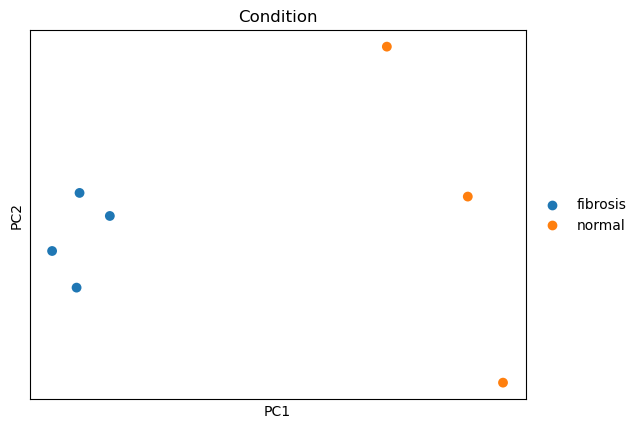

In [67]:
sc.pl.pca(dds, color = 'condition', size = 200, title = 'Condition')

# Heatmap and Hierarchical Clustering

A heatmap visually displays the expression levels of selected genes (usually the most variable or significantly differentially expressed) across samples. Each cell in the grid represents a gene-sample pair, with colors indicating expression intensity.

Hierarchical clustering groups similar genes and/or samples based on expression patterns. This helps reveal:

Co-expressed gene modules,

Sample groupings (e.g., treated vs. control),

Outliers or batch effects.



In [68]:
dds

AnnData object with n_obs × n_vars = 7 × 21835
    obs: 'condition', 'genotype'
    uns: 'trend_coeffs', '_squared_logres', 'prior_disp_var', 'pca', 'condition_colors'
    obsm: 'design_matrix', 'size_factors', 'X_pca'
    varm: 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', '_normed_means', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'PCs'
    layers: 'normed_counts', '_mu_hat', '_mu_LFC', '_hat_diagonals', 'cooks'

In [69]:
#Subset the AnnData object dds to include only the columns (genes) listed in sigs.index.
import numpy as np
dds.layers['normed_counts']
dds.layers['log1p'] = np.log1p(dds.layers['normed_counts'])

dds_sigs = dds[:, sigs.index]

In [70]:
dds_sigs

View of AnnData object with n_obs × n_vars = 7 × 8982
    obs: 'condition', 'genotype'
    uns: 'trend_coeffs', '_squared_logres', 'prior_disp_var', 'pca', 'condition_colors'
    obsm: 'design_matrix', 'size_factors', 'X_pca'
    varm: 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', '_normed_means', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'PCs'
    layers: 'normed_counts', '_mu_hat', '_mu_LFC', '_hat_diagonals', 'cooks', 'log1p'

In [71]:
grapher = pd.DataFrame(dds_sigs.layers['log1p'].T,
                       index=dds_sigs.var_names, columns=dds_sigs.obs_names)

C:\Users\arutherford\AppData\Local\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\arutherford\AppData\Local\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


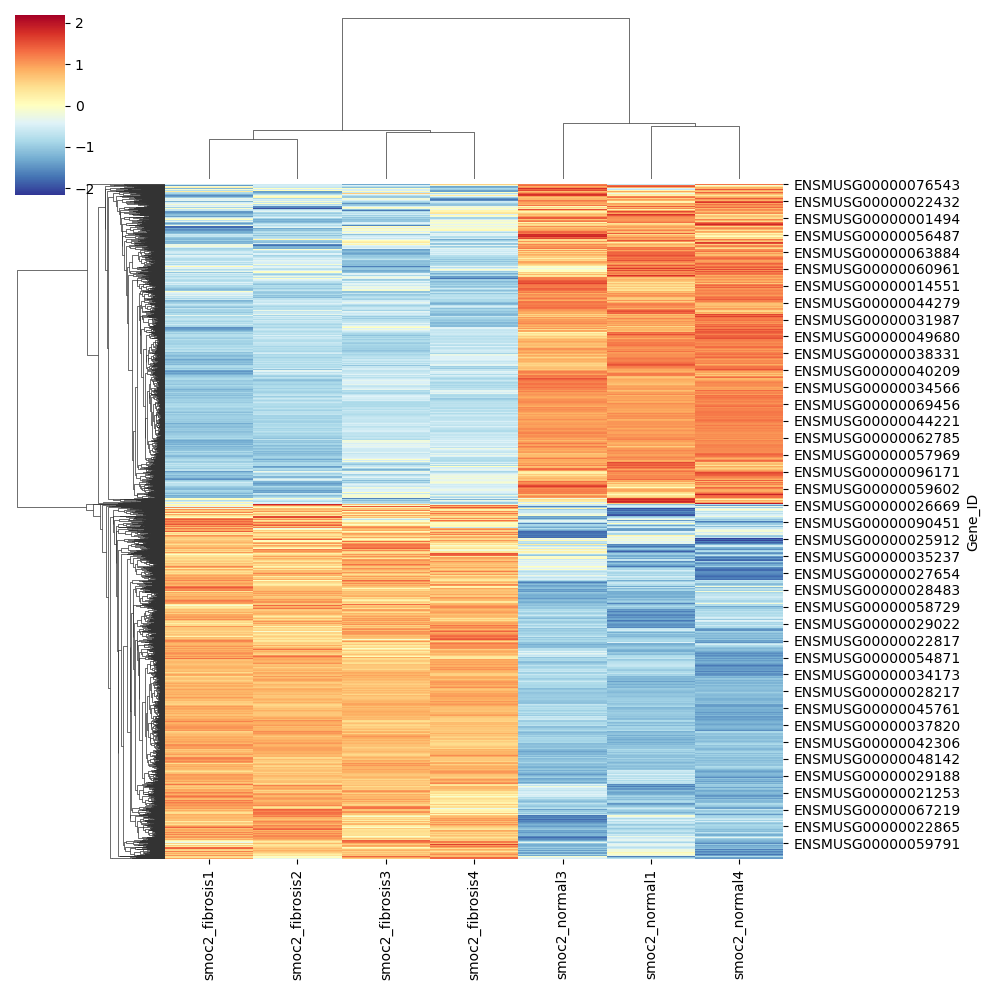

In [72]:
sns.clustermap(grapher, z_score=0, cmap = 'RdYlBu_r')

In [73]:
#Want to update it so that the Gene IDs are displayed rather than the Ensemble IDs
grapher.index = grapher.index.map(mapper.mapper)

In [74]:
grapher

,smoc2_fibrosis1,smoc2_fibrosis2,smoc2_fibrosis3,smoc2_fibrosis4,smoc2_normal1,smoc2_normal3,smoc2_normal4
Gene_ID,,,,,,,
Xkr4,3.937266,3.840976,3.395874,3.357151,0.000000,1.559351,0.778997
Rp1,1.502196,1.303087,2.105375,1.546350,2.802278,3.103801,3.455100
Mrpl15,6.843889,6.877810,6.978133,6.965475,7.499302,7.511410,7.597895
Lypla1,6.955746,7.144531,7.048059,7.045043,8.467338,8.120032,8.504852
Rgs20,2.607829,2.937624,3.251732,2.815457,0.878576,1.559351,1.743470
...,...,...,...,...,...,...,...
NaN,1.985787,1.850230,2.105375,1.878160,2.802278,3.158463,3.101315
NaN,5.576942,5.646722,5.525265,5.749687,6.443703,6.412522,6.569887
Csprs,2.836801,2.201872,2.834543,1.327268,0.000000,0.000000,0.000000


C:\Users\arutherford\AppData\Local\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\arutherford\AppData\Local\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


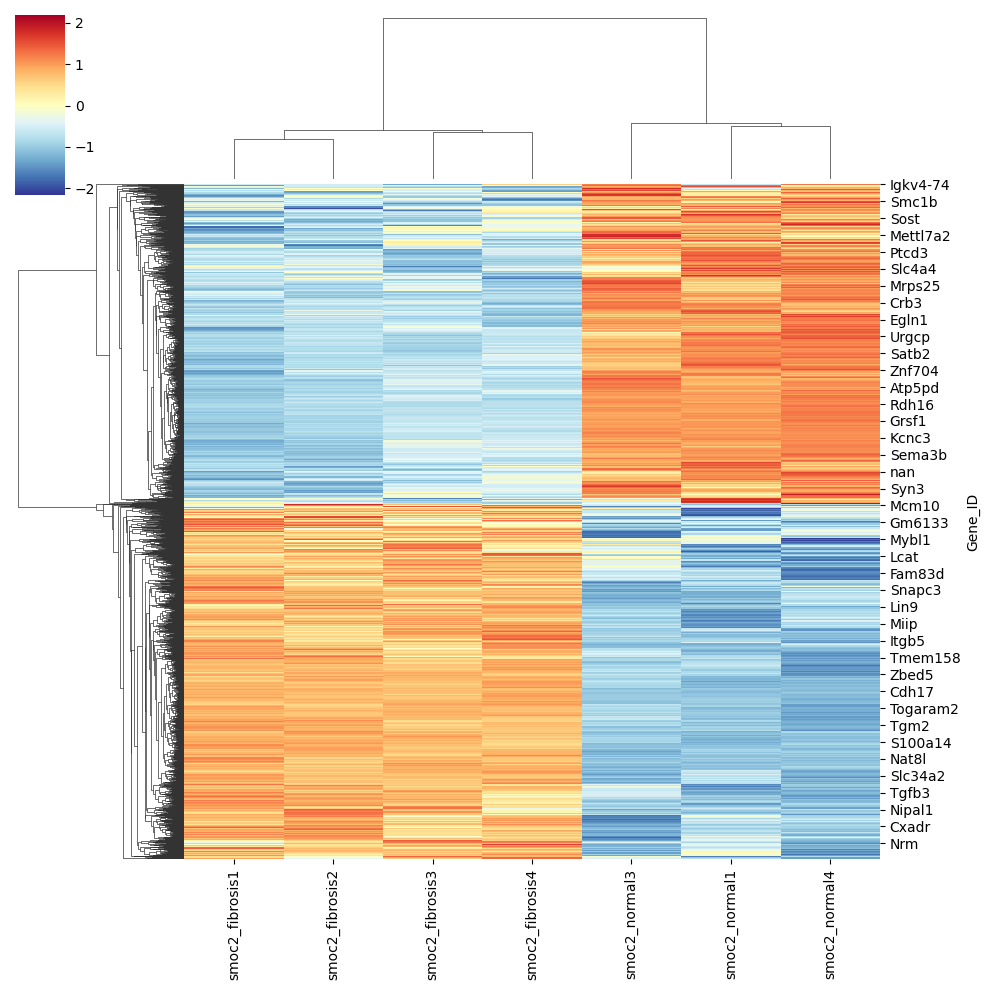

In [75]:
sns.clustermap(grapher, z_score=0, cmap = 'RdYlBu_r')

In [76]:
#volcano
from sanbomics.plots import volcano

In [77]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
Gene_ID,,,,,,,
ENSMUSG00000051951,22.476024,4.497428,0.820912,5.478577,4.287608e-08,1.751001e-07,Xkr4
ENSMUSG00000102331,2.894165,1.705834,1.189912,1.433581,1.516919e-01,2.236525e-01,Gm19938
ENSMUSG00000025900,12.071821,-2.396776,0.583745,-4.105864,4.028065e-05,1.213024e-04,Rp1
ENSMUSG00000025902,347.369139,-0.454565,0.167292,-2.717201,6.583659e-03,1.404341e-02,Sox17
ENSMUSG00000102269,6.700483,-1.445701,0.757294,-1.909034,5.625777e-02,9.552153e-02,NaN
...,...,...,...,...,...,...,...
ENSMUSG00000062783,6.128053,5.523389,2.098513,2.632049,8.487160e-03,1.768876e-02,Csprs
ENSMUSG00000079808,1.780320,3.713039,2.393120,1.551547,1.207705e-01,NaN,AC168977.1
ENSMUSG00000095041,3114.289561,0.896739,0.149223,6.009395,1.862173e-09,8.513381e-09,AC149090.1


0s encountered for p value, imputing 1e-323
impute your own value if you want to avoid this


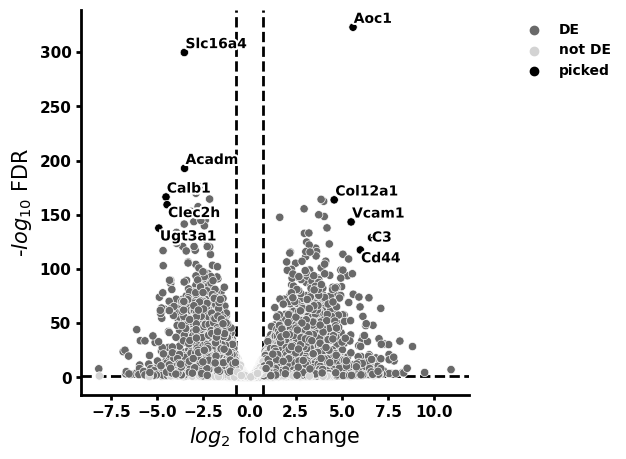

In [78]:
volcano(res, symbol='Symbol')

In [79]:
import matplotlib.pyplot as plt

# Assuming res is your DESeq2 results dataframe
def volcano_plot(res, symbol='Symbol', log2fc_threshold=1, padj_threshold=0.05, top_n=20):
    # Create a new column to classify significant points
    res['Significant'] = 'Not Significant'
    res.loc[(res['padj'] < padj_threshold) & (res['log2FoldChange'] > log2fc_threshold), 'Significant'] = 'Upregulated'
    res.loc[(res['padj'] < padj_threshold) & (res['log2FoldChange'] < -log2fc_threshold), 'Significant'] = 'Downregulated'

    # Transform the p-value into -log10 for visualization
    res['-log10(padj)'] = -np.log10(res['padj'])

    # Sort by padj to get the top N most significant genes
    top_genes = res.nsmallest(top_n, 'padj')

    # Create the plot
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=res, x='log2FoldChange', y='-log10(padj)', hue='Significant',
                    palette={'Upregulated': '#FF6F61', 'Downregulated': '#008080', 'Not Significant': '#D3D3D3'},
                    edgecolor=None, alpha=0.7)

    # Add gene symbols for the top N significant genes
    for i in range(top_genes.shape[0]):
        plt.text(top_genes['log2FoldChange'].iloc[i], top_genes['-log10(padj)'].iloc[i], 
                 top_genes[symbol].iloc[i], fontsize=8)

    # Add a horizontal line for p-adj threshold
    plt.axhline(y=-np.log10(padj_threshold), color='black', linestyle='--', lw=0.7)

    # Add labels
    plt.xlabel('log2 Fold Change')
    plt.ylabel('-log10 Adjusted p-value (FDR)')
    plt.title('Volcano plot for PyDESeq2 Results')
    plt.show()

# Example usage
# volcano_plot(res)


C:\Users\arutherford\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
posx and posy should be finite values
posx and posy should be finite values


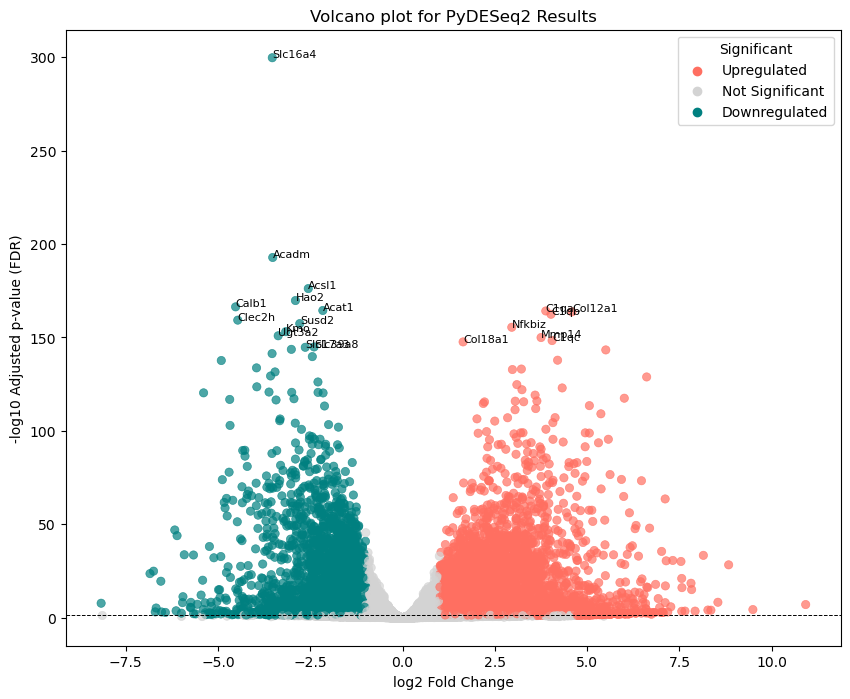

In [80]:
volcano_plot(res)

top_n=20: This parameter controls how many of the top significant genes you want to label (default is 20).

top_genes = res.nsmallest(top_n, 'padj'): This selects the top 20 genes with the smallest adjusted p-values (i.e., most significant).

plt.text(): Now only adds the gene labels for the genes in the top_genes list.


What a Volcano Plot Shows:
The volcano plot combines two key pieces of information:

Fold Change (X-axis): This represents the magnitude of change in gene expression between two conditions, typically expressed as a log2 fold change.

Log2 fold change (log2FC) is used to make the changes more interpretable:
A value of 1 (i.e., log2 fold change of 1) means the gene is expressed 2 times more in one condition compared to the other.
A value of -1 means the gene is expressed 2 times less.
A value of 0 means no change.
Positive values on the x-axis represent upregulated genes, which means they are expressed at higher levels in the test condition.
Negative values represent downregulated genes, expressed at lower levels in the test condition.
Statistical Significance (Y-axis): This is often represented as the negative log10 of the adjusted p-value or FDR.

The adjusted p-value (from methods like Benjamini-Hochberg) accounts for multiple testing corrections. It tells you how likely it is that the gene's change in expression is statistically significant, after correcting for the fact that you're testing many genes.
-log10(p-value) or -log10(FDR) is used to scale p-values so that smaller, more significant p-values appear higher on the plot:
A p-value of 0.01 translates to 2 on the -log10 scale (because log10(0.01) = -2).
A p-value of 0.0001 translates to 4 on the -log10 scale.
The higher up a point is on the plot, the more significant the result (i.e., the smaller the adjusted p-value or FDR).
Plot Interpretation:
Genes in the upper left or right corners of the volcano plot are of greatest interest:
Upregulated genes: These are to the far right (positive log2 fold change) and are statistically significant (high on the y-axis).
Downregulated genes: These are to the far left (negative log2 fold change) and are also statistically significant (high on the y-axis).
Genes near the center (x = 0): These genes have very small or no change in expression between the two conditions.
Points lower on the y-axis: These represent genes with less significant p-values, meaning the change in expression could be due to random variation rather than true biological differences.
Key Features of the Plot:
Thresholds: Volcano plots often include horizontal and vertical lines that help researchers focus on the most meaningful results:
A horizontal line at a certain y-value (e.g., -log10(0.05)) represents the adjusted p-value cutoff, above which genes are considered statistically significant.
Vertical lines may represent fold change cutoffs (e.g., log2FC of ±1 or ±2), showing genes that have a meaningful biological change in expression.
Why Use a Volcano Plot:
Simultaneous Interpretation of Significance and Fold Change: The plot allows you to see both the statistical significance and the magnitude of gene expression change at the same time. This is crucial because you want to identify genes that are both significantly altered and have a biologically relevant change.

Prioritizing Genes for Further Study: Genes with large fold changes and small p-values (upper corners of the plot) are often the most interesting for further analysis, as they are likely to represent real biological differences between conditions.

Example:
Let's say you're comparing gene expression between cancer cells and normal cells:

Upregulated Genes (positive log2FC): If a gene related to cell division appears far to the right and high up, this suggests that it is significantly overexpressed in cancer cells, possibly driving cancer growth.
Downregulated Genes (negative log2FC): If a tumor suppressor gene is far to the left and high up, it may be significantly under-expressed in cancer cells, contributing to the loss of growth control.
By visualizing your data with a volcano plot, you can quickly identify which genes are likely to be important in the biological process you're studying.